<a href="https://colab.research.google.com/github/Rebekah4256/Machine-Learning-Final-Project/blob/main/Machine_Learning_Final_Project_Rebekah_Ryan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo


In [ ]:
#This is importing everything that I need.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics._plot.precision_recall_curve import Counter
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import display
from collections import Counter
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

Original data set from: Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Wine Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T.

In [ ]:
# fetch dataset.
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes).
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata.
print(wine_quality.metadata)

# variable information.
print(wine_quality.variables)


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [ ]:
#Creating a data frame with all the data for EDA.
df = X
df['quality'] = y
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


/tmp/ipython-input-3768416599.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['quality'] = y


In [ ]:
#Seeing what the data looks like.
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
#Checking for any null values.
print(df.isnull().sum())

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [ ]:
#How many wines of each quality there are.
print(df.groupby('quality')['quality'].sum())

quality
3       90
4      864
5    10690
6    17016
7     7553
8     1544
9       45
Name: quality, dtype: int64


/tmp/ipython-input-2046253029.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['quality'].value_counts(), palette='Purples') #bar chart that seperates the categorys and count for the hight


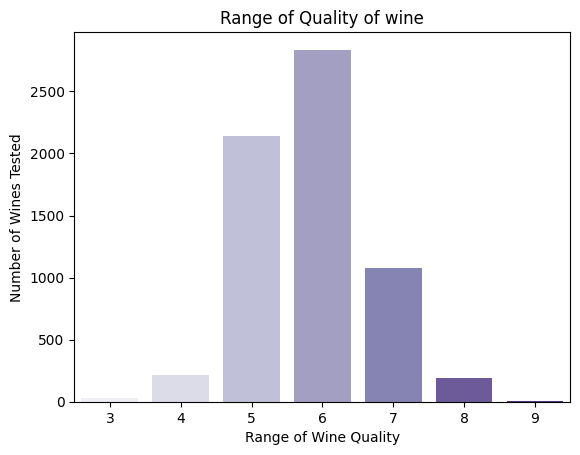

In [ ]:
#Creating a bar chart for how many wines there are of each quality.
sns.barplot(df['quality'].value_counts(), palette='Purples') #bar chart that seperates the categorys and count for the hight
plt.title('Range of Quality of wine') #plot label
plt.xlabel('Range of Wine Quality') #X axsis label
plt.ylabel('Number of Wines Tested') #Y axsis label
plt.show()

From the bar graph, I found that this data is quite skewed, as it shows that there are way more wines that are of a 6 and 5 quality than any other.

In [ ]:
#Making a correlation matrix.
matrix = df.corr()
print(matrix)

                      fixed_acidity  volatile_acidity  citric_acid  \
fixed_acidity              1.000000          0.219008     0.324436   
volatile_acidity           0.219008          1.000000    -0.377981   
citric_acid                0.324436         -0.377981     1.000000   
residual_sugar            -0.111981         -0.196011     0.142451   
chlorides                  0.298195          0.377124     0.038998   
free_sulfur_dioxide       -0.282735         -0.352557     0.133126   
total_sulfur_dioxide      -0.329054         -0.414476     0.195242   
density                    0.458910          0.271296     0.096154   
pH                        -0.252700          0.261454    -0.329808   
sulphates                  0.299568          0.225984     0.056197   
alcohol                   -0.095452         -0.037640    -0.010493   
quality                   -0.076743         -0.265699     0.085532   

                      residual_sugar  chlorides  free_sulfur_dioxide  \
fixed_acidity    

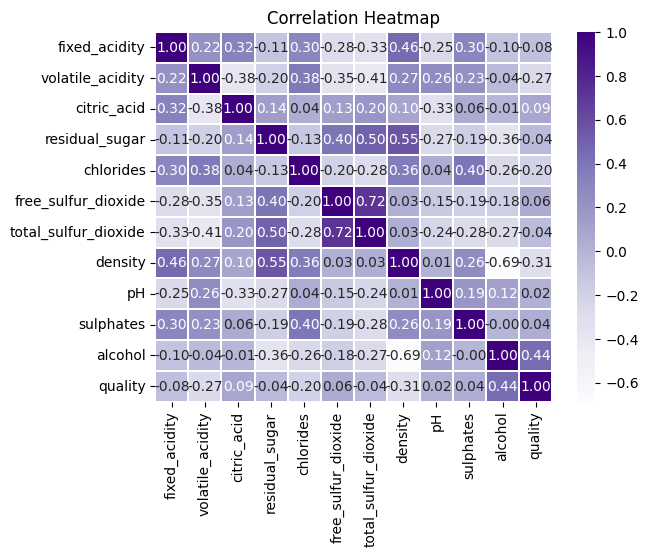

In [ ]:
#Creating a heat map for our correlation matrix
sns.heatmap(matrix, annot=True, cmap="Purples", fmt=".2f", linewidths=0.02)
plt.title("Correlation Heatmap")
plt.show()

What I'm seeing from the heat map it seem the there are quite a few strong to medium correlations between many of the variables.

/tmp/ipython-input-4173456075.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=df, palette="Purples")


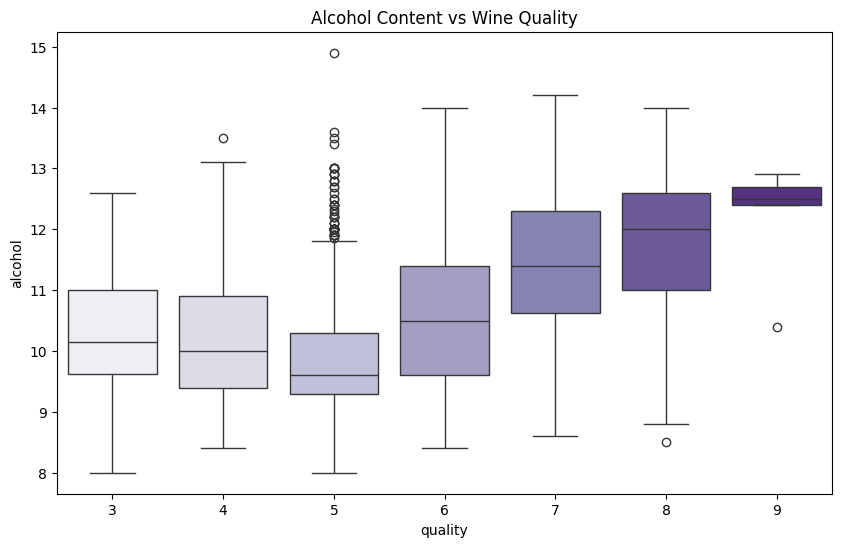

In [ ]:
#Creation a box plot to see the relation ship between the alcohol % and the quality of the wine
plt.figure(figsize=(10,6))
sns.boxplot(x='quality', y='alcohol', data=df, palette="Purples")
plt.title('Alcohol Content vs Wine Quality')
plt.show()

There is a pattern showing that the alcohol percentage may have a pretty big impact.

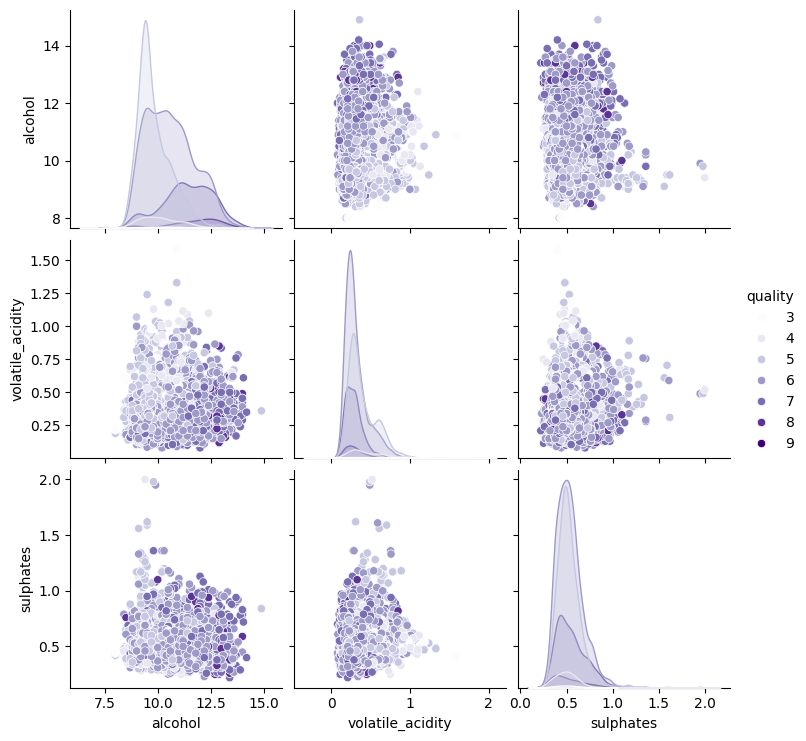

In [ ]:
#Creating a pair plot as to see the relationships between the columns and quality
sns.pairplot(
    df[['alcohol','volatile_acidity','sulphates','quality']],
    hue='quality',
    palette='Purples'
)
plt.show()

In [ ]:
#preparing the X and y for our ML models
X = df.drop('quality', axis='columns')
y = df['quality']

In [ ]:
#splitting the data for traing and testing as well as scaling.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Creating a KNN model as well as finding the perfect number of neighbor #
train_score = {}
test_score = {}
n_neighbors = np.arange(2, 30, 1)
for neighbor in n_neighbors:
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    knn.fit(X_train, y_train)
    train_score[neighbor]=knn.score(X_train, y_train)
    test_score[neighbor]=knn.score(X_test, y_test)

In [ ]:
#printing the numbers that are recommended for neighbor #
for key, value in test_score.items():
    if value==max(test_score.values()):
        print(key)

14
28


In [ ]:
#recreating the KNN with the recomendid neighbor #
knn = KNeighborsClassifier(n_neighbors=14) # Classifier implementing the k-nearest neighbors vote.
knn.fit(X_train, y_train) # Fit the model to our training data
y_pred = knn.predict(X_test) # Make predictions

Text(50.722222222222214, 0.5, 'Actual')

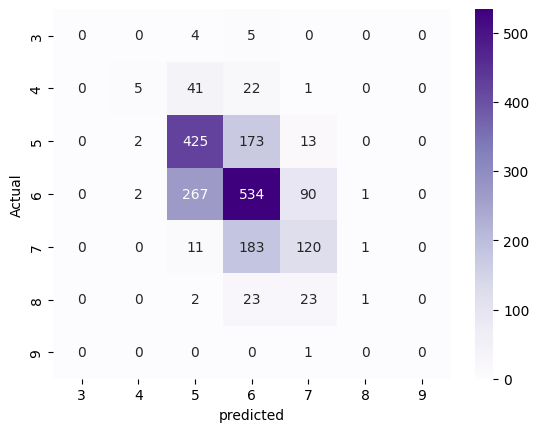

In [ ]:
#creation a confusion matrix with a heat map as to visualize our model
cm = confusion_matrix(y_test , y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=knn.classes_, yticklabels=knn.classes_, cmap='Purples')
plt.xlabel('predicted')
plt.ylabel('Actual')

In [ ]:
#getting the results of how the KNN ML did
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.56      0.07      0.13        69
           5       0.57      0.69      0.62       613
           6       0.57      0.60      0.58       894
           7       0.48      0.38      0.43       315
           8       0.33      0.02      0.04        49
           9       0.00      0.00      0.00         1

    accuracy                           0.56      1950
   macro avg       0.36      0.25      0.26      1950
weighted avg       0.54      0.56      0.54      1950



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#preparing to do a Random Forest Classifier on our data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [ ]:
# Instantiate random forest classifier
classifier = RandomForestClassifier(n_estimators=20, criterion = 'entropy', random_state=42, max_depth= 28)

# Fit the model
classifier.fit(X_train, y_train)

# Predict
y_pred = classifier.predict(X_test)

In [ ]:
#printing how accurate thie ML model is
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")

Accuracy Score: 0.6676923076923077


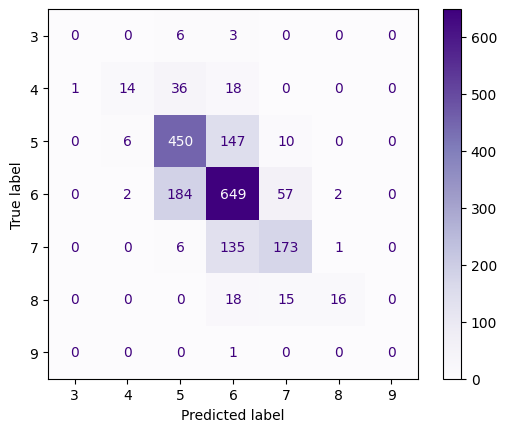

In [ ]:
#creating a confusion matrix to better visualize how our randomforest model did.
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot(cmap = plt.cm.Purples)
plt.show()

In [ ]:
#getting the full accuracy report for thr random forest model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.64      0.20      0.31        69
           5       0.66      0.73      0.69       613
           6       0.67      0.73      0.70       894
           7       0.68      0.55      0.61       315
           8       0.84      0.33      0.47        49
           9       0.00      0.00      0.00         1

    accuracy                           0.67      1950
   macro avg       0.50      0.36      0.40      1950
weighted avg       0.67      0.67      0.66      1950



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
